> Code from https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/ with modifications.

In this seminar, we work with the "airline passengers" dataset, indicating the number of passengers over time. Let's start by loading the data!

Link: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

In [1]:
import pandas as pd
df = pd.read_csv('airline-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [2]:
data_points = df[["Passengers"]].values.astype('float32')
data_points

array([[112.],
       [118.],
       [132.],
       [129.],
       [121.],
       [135.],
       [148.],
       [148.],
       [136.],
       [119.],
       [104.],
       [118.],
       [115.],
       [126.],
       [141.],
       [135.],
       [125.],
       [149.],
       [170.],
       [170.],
       [158.],
       [133.],
       [114.],
       [140.],
       [145.],
       [150.],
       [178.],
       [163.],
       [172.],
       [178.],
       [199.],
       [199.],
       [184.],
       [162.],
       [146.],
       [166.],
       [171.],
       [180.],
       [193.],
       [181.],
       [183.],
       [218.],
       [230.],
       [242.],
       [209.],
       [191.],
       [172.],
       [194.],
       [196.],
       [196.],
       [236.],
       [235.],
       [229.],
       [243.],
       [264.],
       [272.],
       [237.],
       [211.],
       [180.],
       [201.],
       [204.],
       [188.],
       [235.],
       [227.],
       [234.],
       [264.],
       [30

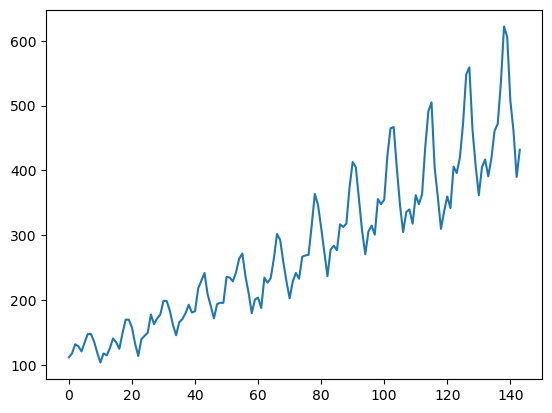

In [3]:
import matplotlib.pyplot as plt
plt.plot(data_points)
plt.show()

In [4]:
train_size = int(len(data_points) * 0.8)
train_data_points = data_points[:train_size]
test_data_points = data_points[train_size:]

sequence_size = 4

import torch

X_train, y_train = [], []
for i in range(len(train_data_points) - sequence_size):
    X_train.append(train_data_points[i:i+sequence_size])
    y_train.append(train_data_points[i+1:i+sequence_size+1])
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_test, y_test = [], []
for i in range(len(test_data_points) - sequence_size):
    X_test.append(test_data_points[i:i+sequence_size])
    y_test.append(test_data_points[i+1:i+sequence_size+1])
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

C:\Users\Seifl\AppData\Local\Temp\ipykernel_17792\826358318.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train = torch.tensor(X_train)


In [5]:
import torch.nn as nn
from tqdm import tqdm

class SimpleRNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=64, num_layers=1, batch_first=True) # batch_first=True: (batch, seq_length, features), the format that comes from DataLoader
        self.linear = nn.Linear(64, 1)
    def forward(self, x):
        x, _ = self.rnn(x)
        x = self.linear(x)
        return x

As https://towardsdatascience.com/pytorch-basics-how-to-train-your-neural-net-intro-to-rnn-cb6ebc594677 says regarding the outputs of the `rnn` function:


- out is the output of the RNN from all timesteps from the last RNN layer. It is of the size (seq_len, batch, num_directions * hidden_size). If batch_first=True, the output size is (batch, seq_len, num_directions * hidden_size).

- h_n is the hidden value from the last time-step of all RNN layers. It is of the size (num_layers * num_directions, batch, hidden_size). h_n is unaffected by batch_first=True

In [6]:
import numpy as np

def training_loop(model, number_of_epochs = 1000):
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train), shuffle=True)
    loss_function = nn.MSELoss() # from PyTorch documentation: measures the mean squared error (squared L2 norm) between each element in the input x and target y
    optimizer = torch.optim.Adam(model.parameters())
    for epoch in tqdm(range(number_of_epochs)):
        model.train()
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            loss = loss_function(y_pred, y_batch)
            optimizer.zero_grad() # for every mini batch in training, set gradients to zero before the backprop
            loss.backward()
            optimizer.step()
        # Validation
        if epoch % 100 == 0 or epoch == number_of_epochs - 1:
            model.eval()
            with torch.no_grad(): # do not update the gradients -> no effect on backprop
                y_pred_train = model(X_train)
                y_pred_test = model(X_test)
                print(f"RMSE for epoch {epoch}: train {np.sqrt(loss_function(y_pred_train, y_train))}, test {np.sqrt(loss_function(y_pred_test, y_test))}")

    with torch.no_grad():
        # shift train predictions for plotting
        train_results = np.ones_like(data_points) * np.nan # an array with the same shape as data_points, filled with NaNs. Stores the training predictions for plotting (if NaN, it is not plotted)
        train_results[4:train_size] = model(X_train)[:, -1, :] # only keep the last prediction for each sequence in the batch
        # shift test predictions for plotting
        test_results = np.ones_like(data_points) * np.nan
        test_results[train_size+4:len(data_points)] = model(X_test)[:, -1, :]
    # plot
    plt.plot(data_points, c='r')
    plt.plot(train_results, c='g')
    plt.plot(test_results, c='b')
    plt.show()

From https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch:

model.train() tells your model that you are training the model. This helps inform layers such as Dropout and BatchNorm, which are designed to behave differently during training and evaluation. For instance, in training mode, BatchNorm updates a moving average on each new batch; whereas, for evaluation mode, these updates are frozen.

  0%|          | 2/1000 [00:00<02:14,  7.41it/s]

RMSE for epoch 0: train 247.63462829589844, test 442.16107177734375


 10%|█         | 101/1000 [00:10<01:28, 10.17it/s]

RMSE for epoch 100: train 38.981449127197266, test 149.50827026367188


 20%|██        | 203/1000 [00:20<01:21,  9.79it/s]

...

RMSE for epoch 800: train 31.137374877929688, test 88.39346313476562


 90%|█████████ | 903/1000 [01:31<00:09, 10.43it/s]

RMSE for epoch 900: train 25.39838218688965, test 84.47268676757812


100%|██████████| 1000/1000 [01:41<00:00,  9.85it/s]

RMSE for epoch 999: train 24.72093391418457, test 82.39141845703125


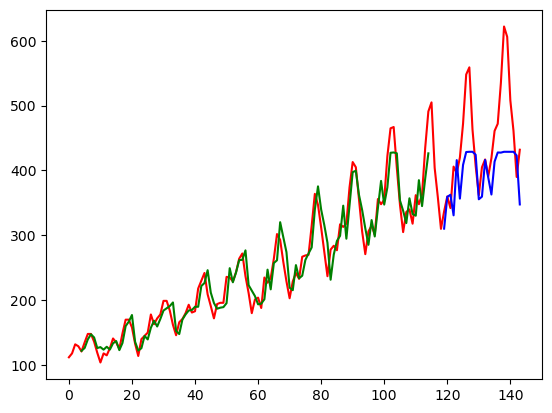

In [7]:
model = SimpleRNNModel()
training_loop(model)

  0%|          | 2/1000 [00:00<02:15,  7.37it/s]

RMSE for epoch 0: train 249.85545349121094, test 444.50299072265625


 10%|█         | 102/1000 [00:12<01:49,  8.19it/s]

RMSE for epoch 100: train 42.614315032958984, test 154.13226318359375


 20%|██        | 202/1000 [00:25<01:40,  7.95it/s]

...

RMSE for epoch 800: train 23.825965881347656, test 78.63827514648438


 90%|█████████ | 902/1000 [01:53<00:12,  7.86it/s]

RMSE for epoch 900: train 23.85904312133789, test 79.67700958251953


100%|██████████| 1000/1000 [02:05<00:00,  7.95it/s]


RMSE for epoch 999: train 23.600299835205078, test 76.03988647460938


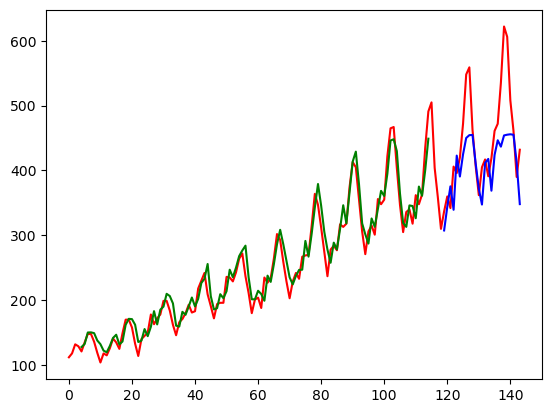

In [8]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
        self.linear = nn.Linear(64, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

model = LSTMModel()
training_loop(model)

  0%|          | 2/1000 [00:00<02:31,  6.59it/s]

RMSE for epoch 0: train 247.79052734375, test 442.3233947753906


 10%|█         | 102/1000 [00:15<02:11,  6.84it/s]

RMSE for epoch 100: train 34.823890686035156, test 133.2947235107422


 20%|██        | 202/1000 [00:30<02:19,  5.71it/s]

...

RMSE for epoch 800: train 24.751346588134766, test 77.15274047851562


 90%|█████████ | 902/1000 [02:18<00:15,  6.26it/s]

RMSE for epoch 900: train 24.976604461669922, test 81.81890106201172


100%|██████████| 1000/1000 [02:34<00:00,  6.49it/s]


RMSE for epoch 999: train 28.205575942993164, test 79.8600082397461


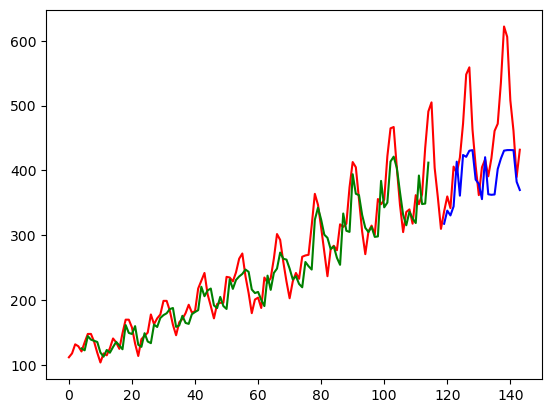

In [9]:
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
        self.linear = nn.Linear(64, 1)
    def forward(self, x):
        x, _ = self.gru(x)
        x = self.linear(x)
        return x
    
model = GRUModel()
training_loop(model)